# Circular UMAP — `ov.pl.plot1cell`

Python port of the R package [**plot1cell**](https://github.com/HaojiaWu/plot1cell)'s
`plot_circlize` (Wu 2021). Clusters become arc sectors on the
unit circle (sector length ∝ `log10(n_cells)`); the UMAP / t-SNE
scatter and KDE contour live *inside* the circle; any list of
`adata.obs` columns you pass to `tracks=` becomes outer
concentric rings.

This notebook walks through **four real scales** — all pulled
straight from [CELLxGENE Discover](https://cellxgene.cziscience.com):

| Scale | Dataset | Cell types | Tracks shown |
|-------|---------|-----------:|---|
| 10k   | Krasnow Lung Cell Atlas (Smart-seq2) | 40 | donor · compartment · sex · age |
| 50k   | Mature kidney | 29 | compartment · tissue · sex · cell_state |
| 100k  | Human distal airways (healthy + COPD) | 44 | disease · tissue · assay · sex · ethnicity |
| 200k  | Lung full cell & nuclei atlas | 23 | smoking · BMI · age · tissue · assay · sex |

Note: above ~10 clusters the function's `label_orient='auto'`
switches from tangent to radial labels so even 40- to 60-type
rings stay readable. With 3-6 tracks you can see plot1cell's
composition-within-sector behaviour on many variables at once.


## Setup

All four datasets are available as public `.h5ad` files from the
CELLxGENE CDN. We cache each under `data/` on first run.


In [1]:
import os, urllib.request
import numpy as np
import pandas as pd
import scanpy as sc
import omicverse as ov
ov.pl.plot_set(font_path='arial')


/home/users/steorra/miniforge3/envs/omicverse/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_loom from `anndata` is deprecated. Import anndata.io.read_loom instead.
  warnings.warn(msg, FutureWarning)


🔬 Starting plot initialization...
Using already downloaded Arial font from: /tmp/omicverse_arial.ttf


INFO:matplotlib.font_manager:Failed to extract font properties from /home/groups/xiaojie/steorra/env/omicverse/fonts/NotoSansMonoCJKhk-VF.ttf: In FT2Font: Can not load face (broken table; error code 0x8)


INFO:matplotlib.font_manager:Failed to extract font properties from /home/groups/xiaojie/steorra/env/omicverse/fonts/NotoSansMonoCJKtc-VF.ttf: In FT2Font: Can not load face (broken table; error code 0x8)


INFO:matplotlib.font_manager:Failed to extract font properties from /home/groups/xiaojie/steorra/env/omicverse/fonts/NotoSansMonoCJKjp-VF.ttf: In FT2Font: Can not load face (broken table; error code 0x8)


...

INFO:matplotlib.font_manager:Failed to extract font properties from /home/groups/xiaojie/steorra/env/omicverse/fonts/NotoSansMonoCJKsc-VF.ttf: In FT2Font: Can not load face (broken table; error code 0x8)


INFO:matplotlib.font_manager:Failed to extract font properties from /home/groups/xiaojie/steorra/env/omicverse/fonts/NotoSansCJKsc-VF.ttf: In FT2Font: Can not load face (broken table; error code 0x8)


INFO:matplotlib.font_manager:Failed to extract font properties from /home/groups/xiaojie/steorra/env/omicverse/fonts/NotoSansMonoCJKkr-VF.ttf: In FT2Font: Can not load face (broken table; error code 0x8)


INFO:matplotlib.font_manager:Failed to extract font properties from /home/groups/xiaojie/steorra/env/omicverse/fonts/NotoSansCJKhk-VF.ttf: In FT2Font: Can not load face (broken table; error code 0x8)


Registered as: Arial
🧬 Detecting GPU devices…
✅ NVIDIA CUDA GPUs detected: 1
    • [CUDA 0] NVIDIA H100 80GB HBM3
      Memory: 79.1 GB | Compute: 9.0

   ____            _     _    __                  
  / __ \____ ___  (_)___| |  / /__  _____________ 
 / / / / __ `__ \/ / ___/ | / / _ \/ ___/ ___/ _ \ 
/ /_/ / / / / / / / /__ | |/ /  __/ /  (__  )  __/ 
\____/_/ /_/ /_/_/\___/ |___/\___/_/  /____/\___/                                              

🔖 Version: 2.1.2rc1   📚 Tutorials: https://omicverse.readthedocs.io/
✅ plot_set complete.



In [2]:
CDN = 'https://datasets.cellxgene.cziscience.com/'
DATA = {
    'lung10k':   'c88e0403-da93-40f4-99b5-f5fdeb81a82c.h5ad',  # Krasnow Smart-seq2
    'kidney50k': '7dafa492-6129-4dff-a794-17bdefde3575.h5ad',  # Mature kidney full
    'airway100k':'861b6b12-f9c9-4434-8d09-695a5156ce23.h5ad',  # distal airways
    'lung200k':  '769fff4f-099a-46e1-917b-06ce1fee858a.h5ad',  # all cells and nuclei
}
os.makedirs('data', exist_ok=True)
def fetch(key):
    local = f'data/{key}.h5ad'
    if not os.path.exists(local):
        print(f'downloading {key}...')
        urllib.request.urlretrieve(CDN + DATA[key], local)
    return local


## Scale 1 — 10 k cells (Krasnow Lung Cell Atlas, Smart-seq2)

9 409 cells × **40 cell types**. This dataset only carries a
**t-SNE** (no UMAP) — `ov.pl.plot1cell` accepts any 2-D
embedding via `basis=`, so we plot against `X_tSNE` directly.
Four tracks: **donor** (3), **compartment** (4 — immune /
epithelial / endothelial / stromal), **sex** (2), **age** (3).


In [3]:
a10k = sc.read_h5ad(fetch('lung10k'))
# Shorten the long development_stage strings for the legend
a10k.obs['age'] = a10k.obs['development_stage'].astype(str).str.replace('-year-old stage', 'y', regex=False)
a10k


AnnData object with n_obs × n_vars = 9409 × 53514
    obs: 'nGene', 'nReads', 'plate.barcode', 'cell.id', 'region', 'label', 'sorter', 'sort.location', 'sample', 'location', 'donor_id', 'percent.ercc', 'percent.ribo', 'gating', 'free_annotation', 'Number of splices: Total', 'Number of splices: Annotated (sjdb)', 'Number of splices: GT-AG', 'Number of splices: GC-AG', 'Number of splices: AT-AC', 'Number of splices: Non-canonical', 'Mapping speed, Million of reads per hour', 'Average input read length', 'compartment', 'tissue_ontology_term_id', 'disease_ontology_term_id', 'development_stage_ontology_term_id', 'assay_ontology_term_id', 'cell_type_ontology_term_id', 'self_reported_ethnicity_ontology_term_id', 'sex_ontology_term_id', 'is_primary_data', 'suspension_type', 'tissue_type', 'cell_type', 'assay', 'disease', 'sex', 'tissue', 'self_reported_ethnicity', 'development_stage', 'observation_joinid', 'age'
    var: 'feature_is_filtered', 'feature_name', 'feature_reference', 'feature_biot

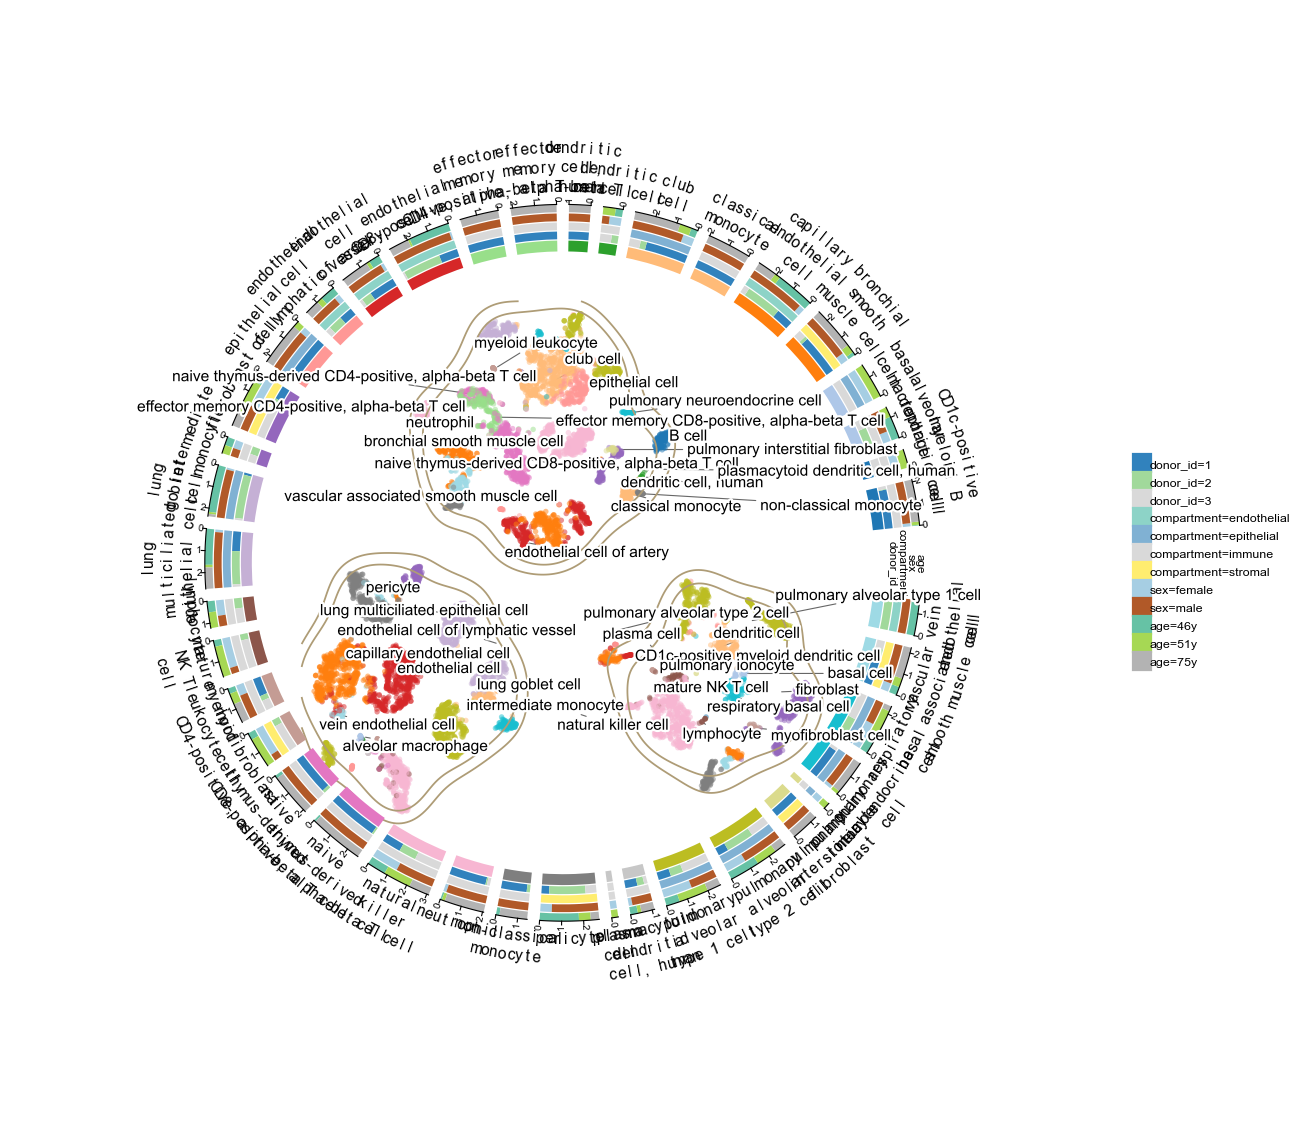

<Axes: >

In [4]:
ov.pl.plot1cell(
    a10k, clusters='cell_type', basis='X_tSNE',
    tracks=['donor_id', 'compartment', 'sex', 'age'],
    point_size=6, point_alpha=0.5,
    figsize=(9, 9), label_fontsize=7,
)


## Scale 2 — 50 k cells (Mature kidney)

40 268 cells × **29 cell types** spanning 5 kidney sub-tissues,
12 donors, mixed pediatric / adult / tumour samples. Four
tracks: **compartment** (proximal tubule / non-PT / lymphoid /
myeloid), **tissue** (cortex / medulla / …), **sex**, and the
`cell_state` (proliferating flag).


In [5]:
a50k = sc.read_h5ad(fetch('kidney50k'))
a50k


AnnData object with n_obs × n_vars = 40268 × 32088
    obs: 'donor_id', 'donor_age', 'self_reported_ethnicity_ontology_term_id', 'sample_uuid', 'tissue_ontology_term_id', 'development_stage_ontology_term_id', 'suspension_uuid', 'suspension_type', 'library_uuid', 'assay_ontology_term_id', 'mapped_reference_annotation', 'is_primary_data', 'cell_type_ontology_term_id', 'author_cell_type', 'cell_state', 'disease_ontology_term_id', 'reported_diseases', 'sex_ontology_term_id', 'Short_Sample', 'Project', 'Experiment', 'compartment', 'broad_celltype', 'tissue_type', 'cell_type', 'assay', 'disease', 'sex', 'tissue', 'self_reported_ethnicity', 'development_stage', 'observation_joinid'
    var: 'feature_is_filtered', 'feature_name', 'feature_reference', 'feature_biotype', 'feature_length', 'feature_type'
    uns: 'citation', 'default_embedding', 'organism', 'organism_ontology_term_id', 'schema_reference', 'schema_version', 'title'
    obsm: 'X_umap'

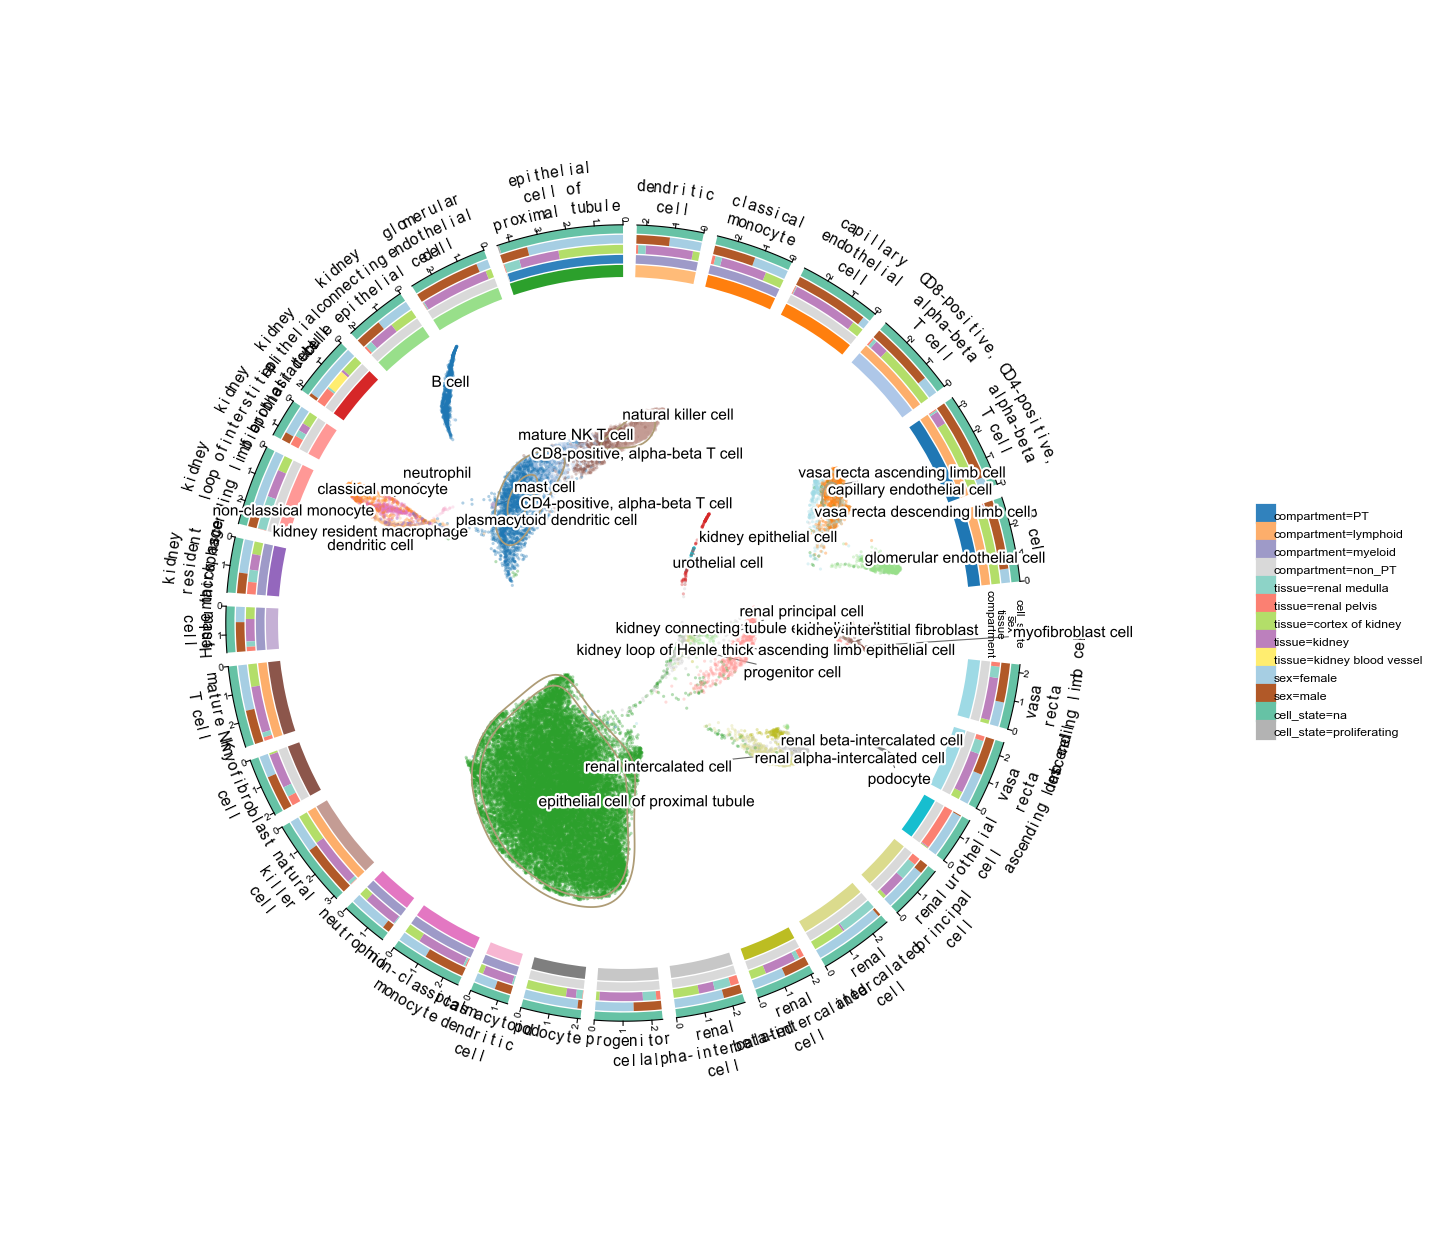

<Axes: >

In [6]:
ov.pl.plot1cell(
    a50k, clusters='cell_type', basis='X_umap',
    tracks=['compartment', 'tissue', 'sex', 'cell_state'],
    point_size=2, point_alpha=0.35,
    figsize=(10, 10), label_fontsize=7,
)


## Scale 3 — 100 k cells (distal airways, healthy + COPD)

115 788 cells × **44 cell types** across 17 donors and two
disease states (`normal` vs. COPD). Five tracks: **disease**,
**tissue** (distal / terminal / proximal airway),
**assay**, **sex**, **self_reported_ethnicity**.

At this scale the scatter is dense — we dial point size + alpha
down so the KDE contour still reads through. Labels are all
radial so the 44 cell types don't collide.


In [7]:
a100k = sc.read_h5ad(fetch('airway100k'))
a100k


AnnData object with n_obs × n_vars = 115788 × 35468
    obs: 'sample_id', 'donor_id', 'protocol_URL', 'institute', 'sample_collection_site', 'sample_collection_relative_time_point', 'library_id', 'library_id_repository', 'author_batch_notes', 'manner_of_death', 'sample_source', 'sex_ontology_term_id', 'sample_collection_method', 'tissue_type', 'sampled_site_condition', 'tissue_ontology_term_id', 'tissue_free_text', 'sample_preservation_method', 'suspension_type', 'cell_enrichment', 'cell_viability_percentage', 'cell_number_loaded', 'sample_collection_year', 'assay_ontology_term_id', 'library_preparation_batch', 'library_sequencing_run', 'sequenced_fragment', 'sequencing_platform', 'reference_genome', 'gene_annotation_version', 'alignment_software', 'intron_inclusion', 'disease_ontology_term_id', 'author_cell_type', 'cell_type_ontology_term_id', 'author_cell_type_markers', 'author_cell_type_description', 'self_reported_ethnicity_ontology_term_id', 'is_primary_data', 'development_stage_o

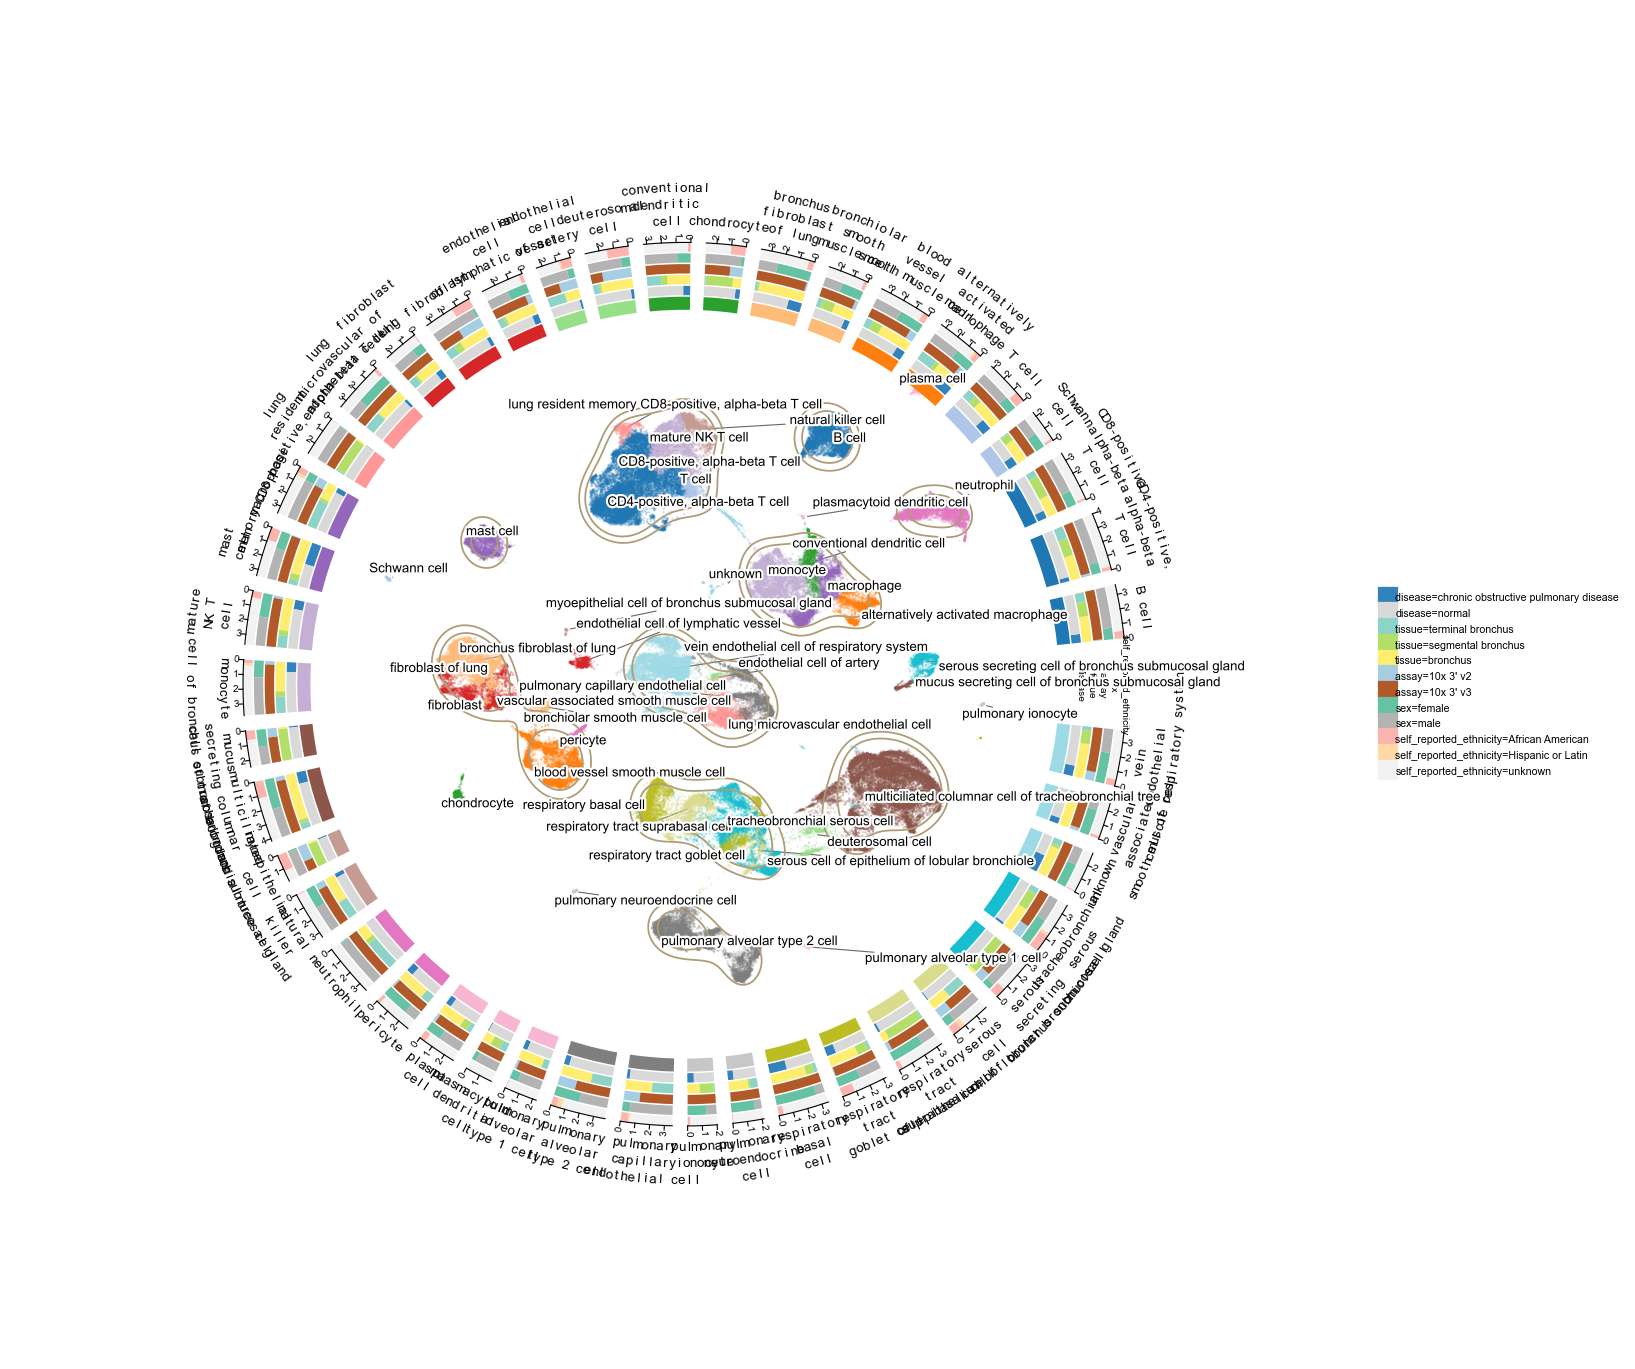

<Axes: >

In [8]:
ov.pl.plot1cell(
    a100k, clusters='cell_type', basis='X_umap',
    tracks=['disease', 'tissue', 'assay', 'sex',
            'self_reported_ethnicity'],
    point_size=1, point_alpha=0.25,
    figsize=(11, 11), label_fontsize=6,
)


## Scale 4 — 200 k cells (Lung all cells and nuclei)

193 108 cells × 60 fine cell types — we use the curator's
mid-level collapse `Celltypes_master_higher_immune` (23 types)
to keep the ring readable. **Six tracks**: smoking status, BMI
range, age range, tissue sub-region, assay, sex.

The full file is ~2 GB. If RAM is tight, you can subsample:
`adata = adata[np.random.choice(adata.n_obs, 50_000, replace=False)]`.
The KDE contour is still smooth at 50k sampled points.


In [9]:
a200k = sc.read_h5ad(fetch('lung200k'))
# Keep fewer genes to reduce memory — plot1cell only needs obsm + obs
a200k = a200k[:, :200].copy()
a200k


AnnData object with n_obs × n_vars = 193108 × 200
    obs: 'Celltypes', 'Celltypes_master_high', 'Celltypes_master_higher', 'Celltypes_master_higher_immune', 'Loc_true', 'suspension_type', 'donor_id', 'Gender', 'Sample', 'ID', 'Protocol_plot', 'assay_ontology_term_id', 'Study', 'PoolDon', 'DonorPool', 'scDonor_snBatch', 'n_genes', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'is_primary_data', 'disease_ontology_term_id', 'donor_id_2', 'sex_ontology_term_id', 'self_reported_ethnicity_ontology_term_id', 'Age range', 'Smoking status', 'Years smoking', 'BMI range', 'development_stage_ontology_term_id', 'Location_long', 'Cell_fraction', 'tissue_ontology_term_id', 'cell_type_ontology_term_id', 'tissue_type', 'cell_type', 'assay', 'disease', 'sex', 'tissue', 'self_reported_ethnicity', 'development_stage', 'observation_joinid'
    var: 'mt', 'n_cells-0', 'n_cells_by_counts-0', 'mean_counts-0', 'pct_dropout_by_counts-0', 'total_counts-0', 'n_cells-1', 'n_cells_by_cou

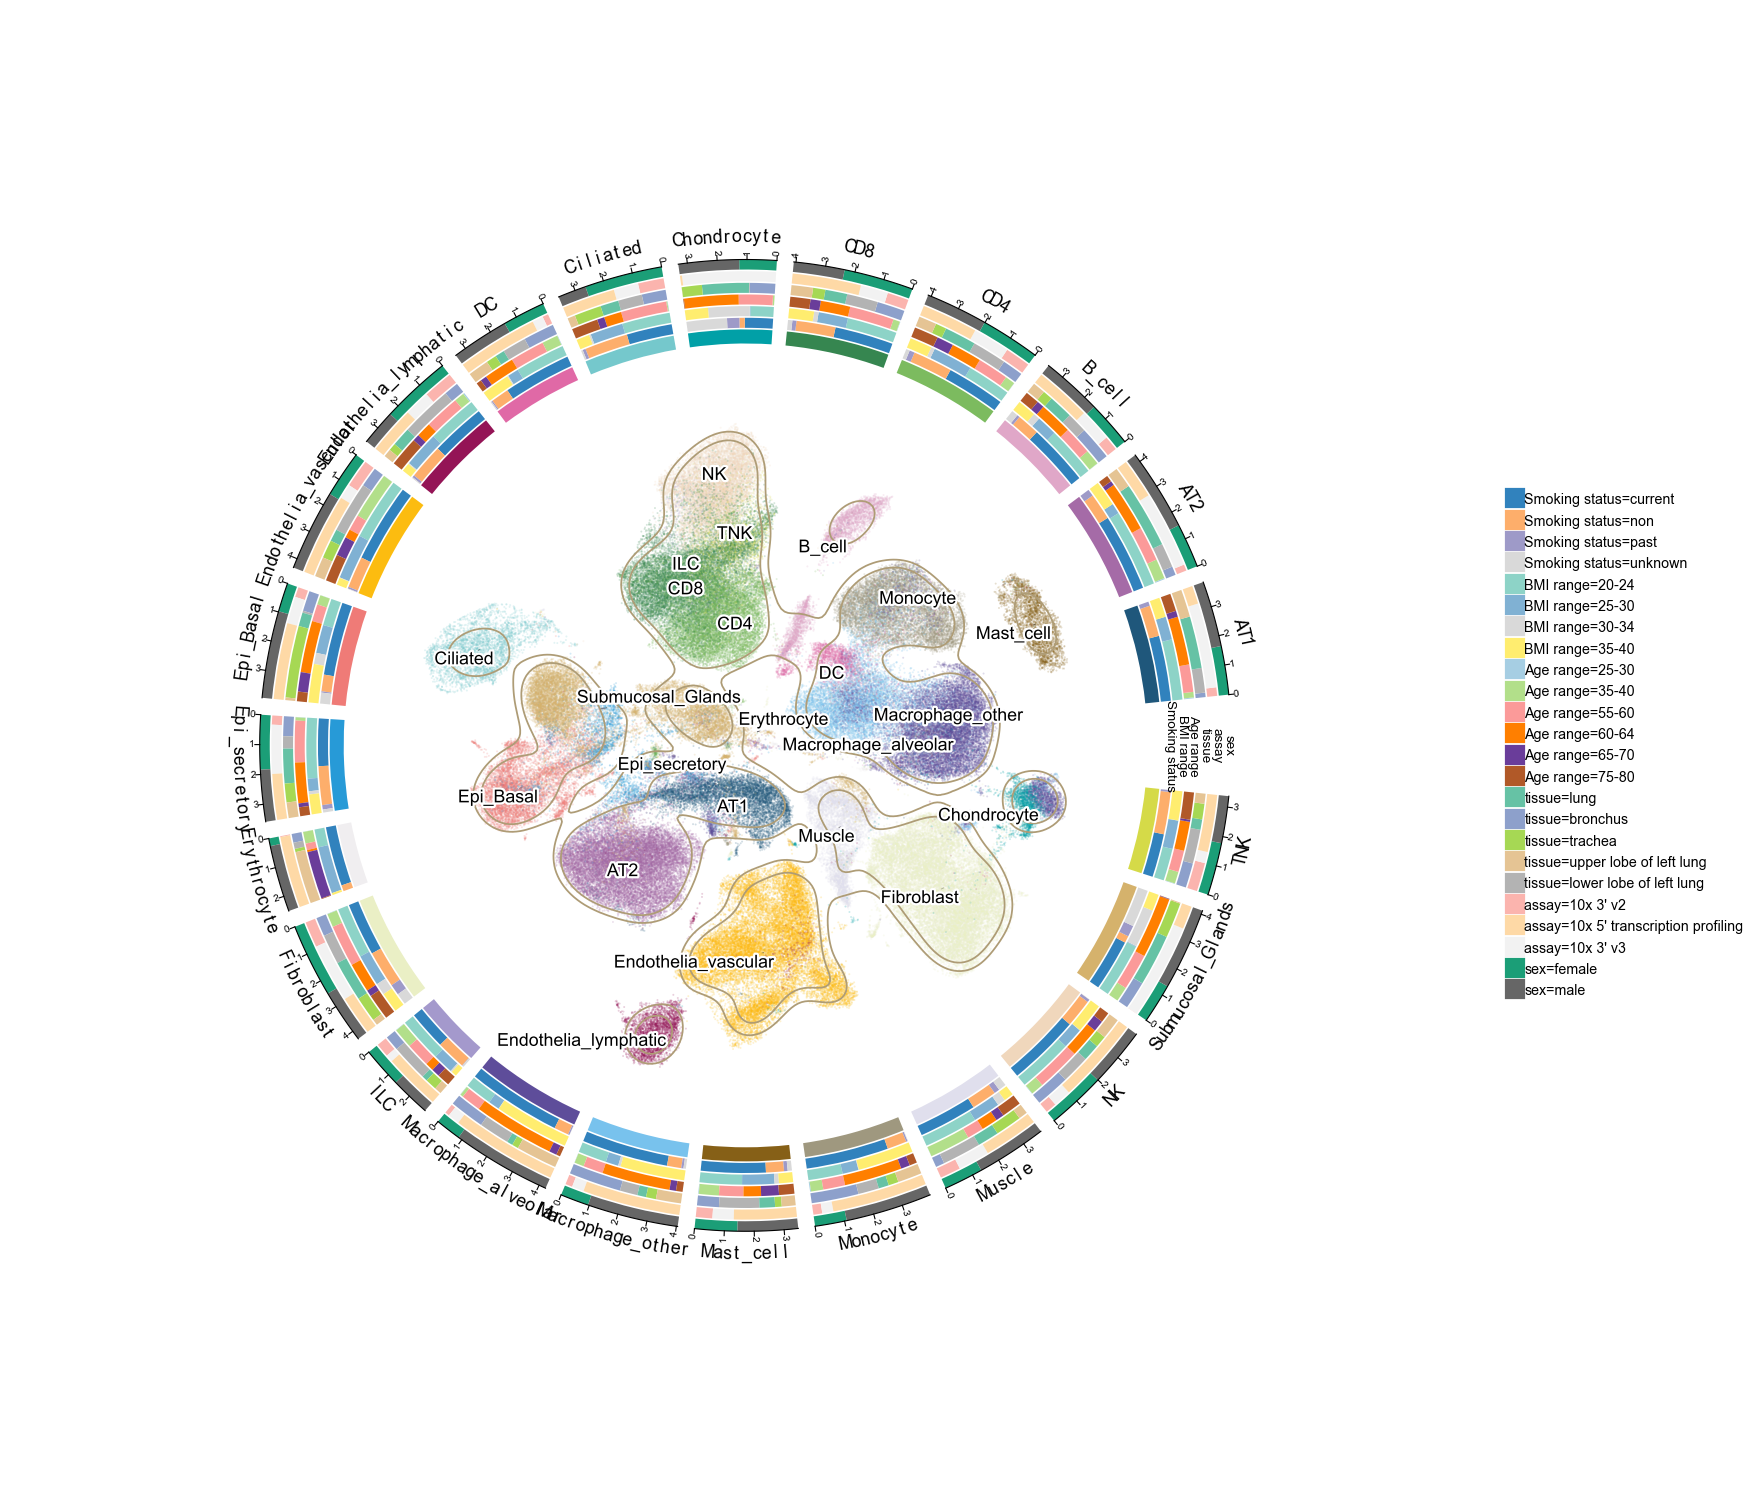

<Axes: >

In [10]:
ov.pl.plot1cell(
    a200k, clusters='Celltypes_master_higher_immune',
    basis='X_umap_Harmony_scDonor_snBatch',
    tracks=['Smoking status', 'BMI range', 'Age range',
            'tissue', 'assay', 'sex'],
    point_size=0.8, point_alpha=0.2,
    figsize=(12, 12), label_fontsize=8,
)


## Key parameters

| Parameter | Purpose |
|-----------|---------|
| `clusters` | obs column with the cluster label (required). |
| `basis` | obsm key, default `'X_umap'`. Any 2-D embedding works (`X_tSNE`, `X_pca`, harmony UMAPs, …). |
| `tracks` | list of obs columns → one concentric ring each, coloured by the run-length composition within each cluster sector. No hard limit; 6 rings render fine. |
| `coord_scale` | how much of the unit circle the scatter fills (0–1, default 0.8). |
| `contour_levels` | KDE levels to overlay; `None` disables. |
| `label_orient` | `'auto'` (default) \| `'tangent'` \| `'radial'`. Auto uses tangent for ≤10 clusters (classic R look) and radial above that so labels never overlap. |
| `gap_between_deg`, `gap_start_deg` | angular gaps between sectors (2°) and at the start of the circle (12°) — match the R convention. |
| `cluster_palette`, `track_palette` | override the default `ov` palette. Accepts a colormap name or a list of colors. |
| `bg_color` | canvas colour (default the R parchment `'#F9F2E4'`). Use `'white'` for a plain look. |
| `point_size`, `point_alpha` | for dense scatters (> 50k points) drop both to keep the KDE contour visible through the cloud. |
| `return_data=True` | also return the per-cell dataframe used internally. |
